# Visualização/Classificação de alunos utilizando métodos não supervisionados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# 1. Carregar os dados
path = 'https://raw.githubusercontent.com/celeron550/Dataset-Alunos-ECT/refs/heads/main/datasets/base_flat_por_aluno.csv'
df = pd.read_csv(path)
df['concluiu'] = df['concluiu'].fillna(-1)
# apenas os que não concluiram
df = df[df['concluiu']==0]

# 2. Filtrando dados
# df_filtered = df[df['total_semestres'] <= 10]

# Apenas avaliando os discentes pelo primeiro periodo
late_cols = [c for c in df.columns if c.startswith(('s2_','s3_','s4_'))]
df_filtered = df.drop(columns=late_cols)
df_filtered = df_filtered[df_filtered['ano_ingresso'] >= 2015]
df_filtered = df_filtered[df_filtered['ano_ingresso'] < 2024]
socio_demo_cols = ['renda', 'sexo_encoded', 'ano_nascimento', 'raca_encoded',
                   'escola_ens_medio_encoded', 'cotista_encoded', 'possui_auxilio_alimentacao','possui_auxilio_residencia_moradia',
                   'periodo_ingresso','possui_auxilio_transporte','possui_bolsa_pesquisa']

df_filtered = df_filtered.drop(columns=(socio_demo_cols + ['id_discente', 'concluiu',
                                                           'semestres_para_concluir',
                                                           'ano_ingresso','periodo_ingresso']))

# Selecionar apenas colunas numéricas
X = df_filtered.select_dtypes(include=[np.number])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

## 2.1 - Reduzir dimensionalidade (PCA)
# Mantendo 30 componentes conforme sua última atualização
pca_nd = PCA(n_components=30)
X_pca = pca_nd.fit_transform(X_scaled)
exp_var_cum_30 = np.cumsum(pca_nd.explained_variance_ratio_)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_pca.fit(X_pca)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
print(X.columns)

Index(['s1_ECT2101_nota', 's1_ECT2101_status', 's1_ECT2102_nota',
       's1_ECT2102_status', 's1_ECT2103_nota', 's1_ECT2103_status',
       's1_ECT2104_nota', 's1_ECT2104_status', 's1_ECT2105_nota',
       's1_ECT2105_status', 's1_ECT2106_nota', 's1_ECT2106_status',
       's1_ECT2201_nota', 's1_ECT2201_status', 's1_ECT2202_nota',
       's1_ECT2202_status', 's1_ECT2203_nota', 's1_ECT2203_status',
       's1_ECT2204_nota', 's1_ECT2204_status', 's1_ECT2205_nota',
       's1_ECT2205_status', 's1_ECT2206_nota', 's1_ECT2206_status',
       's1_ECT2207_nota', 's1_ECT2207_status', 's1_ECT2301_nota',
       's1_ECT2301_status', 's1_ECT2302_nota', 's1_ECT2302_status',
       's1_ECT2303_nota', 's1_ECT2303_status', 's1_ECT2304_nota',
       's1_ECT2304_status', 's1_ECT2305_nota', 's1_ECT2305_status',
       's1_ECT2306_nota', 's1_ECT2306_status', 's1_ECT2307_nota',
       's1_ECT2307_status', 's1_ECT2401_nota', 's1_ECT2401_status',
       's1_ECT2402_nota', 's1_ECT2402_status', 's1_ECT2403_not

In [ ]:
import joblib
df_filtered.to_csv('teste.csv',index=False)
joblib.dump(kmeans, 'kmeans.joblib')
joblib.dump(kmeans_pca, 'kmeans-pca.joblib')

['kmeans-pca.joblib']

In [ ]:
print(f'{exp_var_cum_30[-1]}')

0.9940723045515011


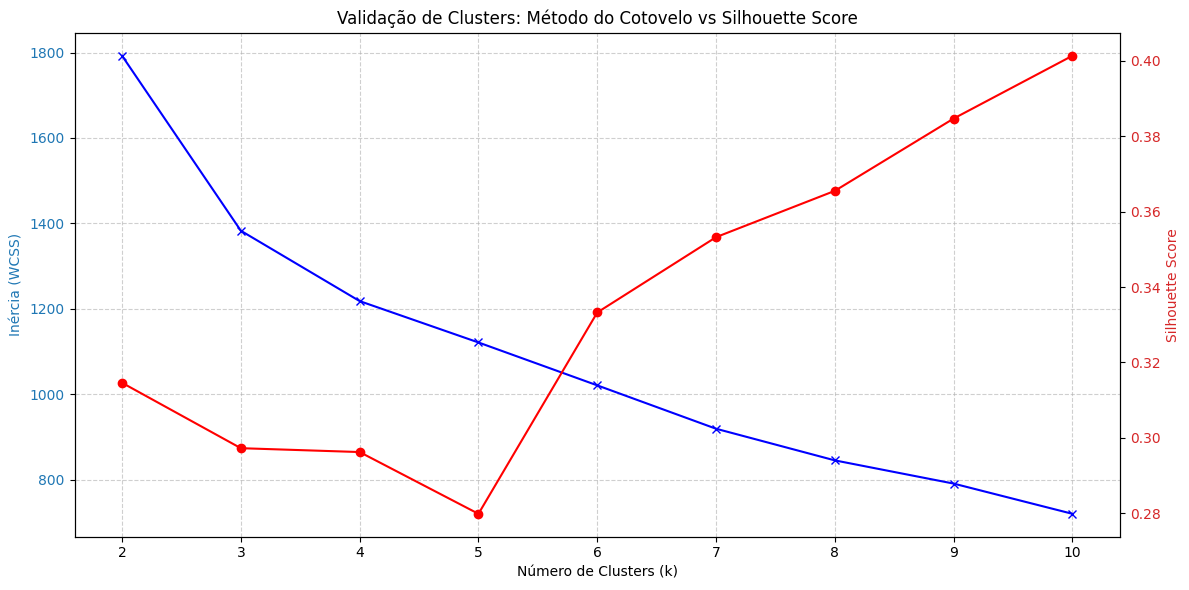

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

inertia = []
silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, labels))

# Criando o gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo 1: Inércia (WCSS)
color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (WCSS)', color=color)
ax1.plot(k_range, inertia, 'bx-', label='Inércia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Eixo 2: Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_avg, 'ro-', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Validação de Clusters: Método do Cotovelo vs Silhouette Score')
fig.tight_layout()
plt.show()

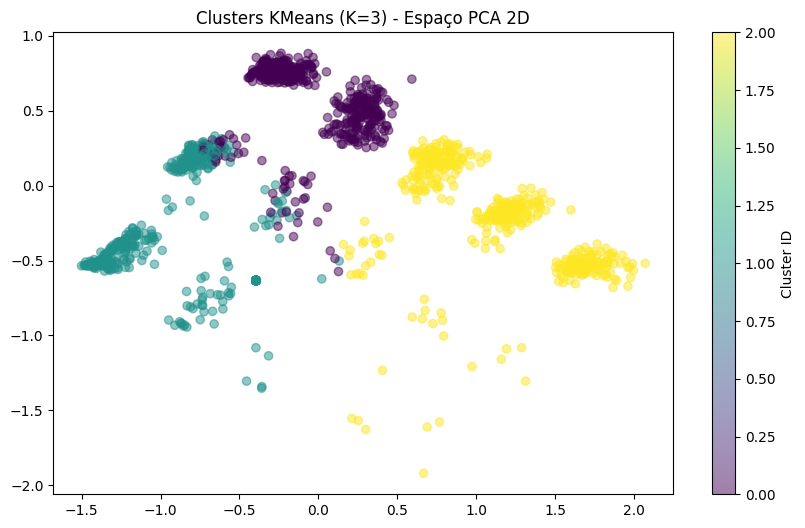

In [ ]:
# 5. Visualização do KMeans: Projeção direta dos dados escalonados para 3D
pca_vis_km = PCA(n_components=3)
pca_3d = pca_vis_km.fit_transform(X_scaled)

# Adicionando as coordenadas do PCA e os labels do KMeans ao DataFrame
df_filtered['pca_1'] = pca_3d[:, 0]
df_filtered['pca_2'] = pca_3d[:, 1]
df_filtered['pca_3'] = pca_3d[:, 2]
df_filtered['cluster_kmeans'] = kmeans.labels_.astype(str)

# Plot 2D dos Clusters (Matplotlib)
plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['pca_1'], df_filtered['pca_2'], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.title(f'Clusters KMeans (K=3) - Espaço PCA 2D')
plt.colorbar(label='Cluster ID')
plt.show()

# Plot 3D Interativo (Plotly)
fig_3d = px.scatter_3d(
    df_filtered,
    x='pca_1',
    y='pca_2',
    z='pca_3',
    color='cluster_kmeans', # Nome da coluna criada acima
    title='Nuvem de Pontos 3D - Clusters KMeans',
    opacity=0.6,
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_3d.show()

In [ ]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=df3ac559d3a42d07e413734c2028c019343ceef020de28bb3f6ddb9c7560284b
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
from minisom import *
# Ajustando o SOM para um grid maior e topologia hexagonal
size = 3
som = MiniSom(size, size, X_pca.shape[1], sigma=1.5, learning_rate=0.5,
              topology='hexagonal', random_seed=42)
som.pca_weights_init(X_pca)
som.train_random(X_pca, 2000, verbose=True)

# Extração dos novos Clusters
winner_coordinates = np.array([som.winner(x) for x in X_pca])
som_clusters = winner_coordinates[:, 0] * size + winner_coordinates[:, 1]
df_filtered['som_cluster'] = som_clusters

# Recalcular Métricas
q_error = som.quantization_error(X_pca)
t_error = som.topographic_error(X_pca)

print(f'Novo Erro de Quantização: {q_error:.4f}')
print(f'Novo Erro Topográfico: {t_error:.4f}')
joblib.dump(som, 'modelo_som.joblib')
# Visualização 3D atualizada
fig_3d = px.scatter_3d(
    df_filtered, x='pca_1', y='pca_2', z='pca_3',
    color='som_cluster',
    title=f'SOM {size}x{size} (Topo: Hex) - Erro Topo: {t_error:.2%}',
    color_continuous_scale='Viridis',
    opacity=0.7
)
fig_3d.show()

 [ 2000 / 2000 ] 100% - 0:00:00 left 
 quantization error: 0.7210871950344699
Novo Erro de Quantização: 0.7211
Novo Erro Topográfico: 0.0764


In [ ]:
import numpy as np

# 1. Erro Topográfico: Proporção de dados onde o 1º e 2º neurônios vencedores não são vizinhos
t_error = som.topographic_error(X_pca)

# 2. Erro de Quantização relativo à variância (proporção)
# Uma métrica simples de distorção
print(f'Erro de Quantização: {q_error:.4f}')
print(f'Erro Topográfico: {t_error:.4f} (Idealmente próximo de 0)')

if t_error > 0.1:
    print('\nNota: O erro topográfico está acima de 10%, sugerindo que o grid pode estar pequeno ou muito rígido para a complexidade dos dados.')
else:
    print('\nNota: O erro topográfico está baixo, indicando que a topologia dos dados foi bem preservada pelo SOM.')



Erro de Quantização: 0.7211
Erro Topográfico: 0.0764 (Idealmente próximo de 0)

Nota: O erro topográfico está baixo, indicando que a topologia dos dados foi bem preservada pelo SOM.


In [ ]:
import joblib
import plotly.express as px

# 1. Carregar os modelos
kmeans_loaded = joblib.load('kmeans.joblib')
kmeans_pca_loaded = joblib.load('kmeans-pca.joblib')
som_loaded = joblib.load('modelo_som.joblib')

print("Modelos carregados com sucesso!")

# 2. Testar o KMeans Carregado (usando labels salvos ou predizendo)
# Para visualização, vamos usar os labels que já estão no dataframe para comparação
fig_km_loaded = px.scatter_3d(
    df_filtered,
    x='pca_1', y='pca_2', z='pca_3',
    color='cluster_kmeans',
    title='Teste: Clusters KMeans (Modelo Carregado)',
    opacity=0.6
)
fig_km_loaded.show()

# 3. Testar o SOM Carregado
# Recalculando coordenadas vencedoras para garantir que o modelo SOM está operacional
winner_coords_loaded = np.array([som_loaded.winner(x) for x in X_pca])
som_clusters_loaded = winner_coords_loaded[:, 0] * 3 + winner_coords_loaded[:, 1]

fig_som_loaded = px.scatter_3d(
    df_filtered, x='pca_1', y='pca_2', z='pca_3',
    color=som_clusters_loaded.astype(str),
    title='Teste: Clusters SOM (Modelo Carregado)',
    color_continuous_scale='Viridis',
    opacity=0.7
)
fig_som_loaded.show()

Modelos carregados com sucesso!


# invocando o brabo


In [ ]:
import numpy as np
# Classe do Growing Neural Gas ajustado com transições
class GrowingNeuralGas:
    def __init__(self, n_inputs, n_start_nodes=2, max_nodes=10, alpha=0.4, beta=0.001, multi = 100, epochs=100, Omega = 0.5, Delta = 0.0005,fracao_K = 0.00005):
        # Quantidade de caracteristicas
        self.n_inputs = n_inputs
        #Numero inicial de Nodes
        self.n_start_nodes = n_start_nodes
        #Numero maximo
        self.max_nodes = max_nodes
        #O quanto o node mais proximo se aproxima do dado
        self.alpha = alpha
        #o quanto os nodes vizinhos de movem em direção ao dado
        self.beta = beta
        self.multi= multi # Frequência de inserção (lambda)
        self.epochs = epochs
        #Decaimento do erro ao adicionar um novo nó
        self.Omega = Omega
        #Decaimento goblal do erro em cada Epoch
        self.Delta = Delta
        #Valor para definir se remove ou nao o nó
        self.fracao_K = fracao_K

        self.nodes = np.random.rand(self.n_start_nodes, n_inputs)
        self.errors = np.zeros(self.n_start_nodes)

        # Estrutura de Topologia: {nó_A: {nó_B: 0, nó_C: 0}, ...}
        self.Arestas = {i: {} for i in range(self.n_start_nodes)}
        if self.n_start_nodes >= 2:
            self.Arestas[0][1] = 0
            self.Arestas[1][0] = 0

        #Fator de Utilidade
        self.FU = np.zeros(self.n_start_nodes)
        self.transitions = []
        self.listaN = {}

    def train(self, data, lista, neuronios):
        self.transitions = lista.copy()
        self.listaN = neuronios.copy()
        num_dados = len(data)
        if num_dados > len(self.transitions):
            self.transitions.extend([] for _ in range(num_dados - len(self.transitions)))
        for epoch in range(self.epochs):
            if len(self.nodes) > 2:
                i = 0
                while i < len(self.nodes):
                    # Calcula distâncias euclidianas ao quadrado de uma vez
                    diff_P = self.nodes - self.nodes[i]
                    proximidade = np.sum(diff_P**2, axis=1)
                    # Encontra o vizinho mais próximo (excluindo o próprio nó)
                    proximidade[i] = np.inf  # Ignora a si mesmo
                    MP = np.argmin(proximidade)
                    if proximidade[MP] < 0.05:
                        self.remove_node(MP)
                        # Ajusta o índice se removeu um nó anterior
                        if MP < i:
                            i -= 1
                    else:
                        i += 1
            x = 0
            while x < num_dados:
                if np.isnan(data[x]).any() == False:
                    # 1. Busca BMU
                    data_point = data[x]
                    diff = self.nodes - data_point
                    dist_sq = np.sum(diff**2, axis=1)
                    sorted_indices = np.argsort(dist_sq)
                    bmu_idx = sorted_indices[0]
                    second_bmu_idx = sorted_indices[1]

                  # Registro de transição no último epoch
                    if epoch == self.epochs - 1:
                        self.transitions[x].append(int(bmu_idx))

                        if len(self.transitions[x]) >= 2:
                          ultimos = self.transitions[x][-2:]

                          if "vazio" not in ultimos:
                            chave = (tuple(ultimos), len(self.transitions[x]))
                            self.listaN[chave] = self.listaN.get(chave, 0) + 1
                    else:
                      # 2. Atualização do BMU e vizinhos (topológica)
                      self.nodes[bmu_idx] += self.alpha * (data_point - self.nodes[bmu_idx])

                      # Otimizado para vizinhos topológicos
                      lista_dos_ligados_ao_no = list(self.Arestas[bmu_idx].keys())
                      for ligado in lista_dos_ligados_ao_no:
                          self.nodes[ligado] += self.beta * (data_point - self.nodes[ligado])

                      # Reconecta BMU e SBMU
                      self.Arestas[bmu_idx][second_bmu_idx] = 0
                      self.Arestas[second_bmu_idx][bmu_idx] = 0

                      # 3. Erro acumulado e Fator de Utilidade
                      self.errors[bmu_idx] += dist_sq[bmu_idx]
                      self.FU[bmu_idx] += self.errors[bmu_idx] - self.errors[second_bmu_idx]


                      # 4. Inserção de Novo Nó
                      if (len(self.nodes) < self.max_nodes) and (x % self.multi == 0):
                          self.add_new_node()

                      # 5. Remoção por Fator de Utilidade
                      menor_FU_indice = np.argmin(self.FU)
                      if np.max(self.errors) > 0 and (self.FU[menor_FU_indice] / np.max(self.errors)) < self.fracao_K and (len(self.nodes) > 2):
                        self.remove_node(menor_FU_indice)
                else:
                    # Gap → registra "vazio" no último epoch
                    if epoch == self.epochs - 1:
                        self.transitions[x].append("vazio")
                        if len(self.transitions[x]) >= 2:
                          ultimos = self.transitions[x][-2:]
                          chave = (tuple(ultimos), len(self.transitions[x]))
                          self.listaN[chave] = self.listaN.get(chave, 0) + 1

                # Decaimento global
                self.errors = self.errors - self.Delta*self.errors
                self.FU = self.FU - self.Delta*self.FU
                x += 1
    def add_new_node(self):
        # Encontra Wmu (nó com maior erro) e seu vizinho Wv (vizinho de maior erro)
        wmu_idx = np.argmax(self.errors)
        lista_dos_ligados_ao_no = list(self.Arestas.get(wmu_idx, {}).keys())

        if not lista_dos_ligados_ao_no: return # Não insere se Wmu estiver isolado

        second_wmu_idx = lista_dos_ligados_ao_no[0]
        novo_indice = len(self.nodes)

        for ligado in lista_dos_ligados_ao_no:
            if self.errors[ligado] > self.errors[second_wmu_idx]:
                second_wmu_idx = ligado # Encontramos Wv

        # Adiciona novo nó no meio de Wmu e Wv
        new_node = (self.nodes[wmu_idx] + self.nodes[second_wmu_idx]) / 2
        self.nodes = np.vstack([self.nodes, new_node])
        # Erro inicial do novo nó é o Erro(Wmu) * Omega
        self.errors = np.append(self.errors, self.errors[wmu_idx])
        self.FU = np.append(self.FU, (self.FU[wmu_idx] + self.FU[second_wmu_idx]) / 2)

        # Decaimento do Erro nos pais
        self.errors[wmu_idx] = self.errors[wmu_idx] * self.Omega
        self.errors[second_wmu_idx] = self.errors[second_wmu_idx] * self.Omega

        # Atualiza Topologia (reindexando e criando/deletando arestas)
        self.Arestas[novo_indice] = {}

        # Remove a aresta antiga
        del self.Arestas[wmu_idx][second_wmu_idx]
        del self.Arestas[second_wmu_idx][wmu_idx]

        # Adiciona as duas novas arestas
        self.Arestas[wmu_idx][novo_indice] = 0
        self.Arestas[novo_indice][wmu_idx] = 0
        self.Arestas[second_wmu_idx][novo_indice] = 0
        self.Arestas[novo_indice][second_wmu_idx] = 0


    def remove_node(self, idx_removido):

        # 1. Remove referências na Topologia
        if idx_removido in self.Arestas:
            vizinhos = list(self.Arestas[idx_removido].keys())

            for vizinho_id in vizinhos:
                if idx_removido in self.Arestas.get(vizinho_id, {}):
                    del self.Arestas[vizinho_id][idx_removido]

            del self.Arestas[idx_removido]

        # 2. Remover Elementos dos Arrays NumPy
        self.nodes = np.delete(self.nodes, idx_removido, axis=0)
        self.errors = np.delete(self.errors, idx_removido, axis=0)
        self.FU = np.delete(self.FU, idx_removido, axis=0)

        # 3. Reindexar a Topologia
        new_adj = {}
        for old_id, vizinhos in self.Arestas.items():
            new_id = old_id if old_id < idx_removido else old_id - 1
            new_vizinhos = {}
            for vizinho_old_id, value in vizinhos.items():
                vizinho_new_id = vizinho_old_id if vizinho_old_id < idx_removido else vizinho_old_id - 1
                new_vizinhos[vizinho_new_id] = value
            new_adj[new_id] = new_vizinhos
        self.Arestas = new_adj

In [ ]:
def plot_gng(x_data, gng_model):
    # Projeta os dados de treino (X_pca ou X_scaled) para 2D para visualização
    pca_vis = PCA(n_components=2)
    x_pca_vis = pca_vis.fit_transform(x_data)
    nodes_pca_vis = pca_vis.transform(gng_model.nodes)

    plt.figure(figsize=(10, 6))
    # Desenha os dados de fundo
    plt.scatter(x_pca_vis[:, 0], x_pca_vis[:, 1], label='Dados', alpha=0.2, c='gray', s=10)

    # Desenha as conexões (arestas) entre os neurônios
    for node_idx, connections in gng_model.Arestas.items():
        for neighbor_idx in connections.keys():
            if node_idx < neighbor_idx:
                plt.plot([nodes_pca_vis[node_idx, 0], nodes_pca_vis[neighbor_idx, 0]],
                         [nodes_pca_vis[node_idx, 1], nodes_pca_vis[neighbor_idx, 1]],
                         'r-', alpha=0.6, lw=1.5)

    # Desenha os neurônios
    plt.scatter(nodes_pca_vis[:, 0], nodes_pca_vis[:, 1], color='red', label='Neurônios GNG', s=80, edgecolors='black', zorder=5)

    for i, (x_coord, y_coord) in enumerate(nodes_pca_vis):
        plt.text(x_coord, y_coord, str(i), color='black', fontsize=12, fontweight='bold')

    plt.title('Topologia Aprendida pelo GNG (Projeção 2D)')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
gng = GrowingNeuralGas(n_inputs=30) # 30 = dimensao do X_pca


gng.train(X_pca,[],{})

In [ ]:
gng_s = GrowingNeuralGas(n_inputs=X_scaled.shape[1])
gng_s.train(X_scaled,[],{})

# Topologia GNG: O gráfico abaixo mostra a 'espinha dorsal' (arestas vermelhas) que conecta os neurônios. Se os neurônios estão bem distribuídos sobre a massa cinza (os dados), o GNG conseguiu aprender a estrutura local. Se houvessem muitos neurônios isolados ou amontoados, poderia ser necessário aumentar o número de épocas ou ajustar o learning_rate do modelo.

## As conexoes indicam que existe uma continuidade ou semelhança estatística entre esses nós (neuronios).
- Se há uma linha longa ligando dois grupos, a rede está dizendo que existe uma transição ou caminho entre esses perfis de alunos.
- Se há neurônios sem conexões (isolados), eles representam grupos de alunos com comportamentos muito únicos que não se conectam com o restante da massa.
- Se as conexões formam uma 'teia' muito densa, os dados não têm separações nítidas, mas sim uma distribuição contínua de características.

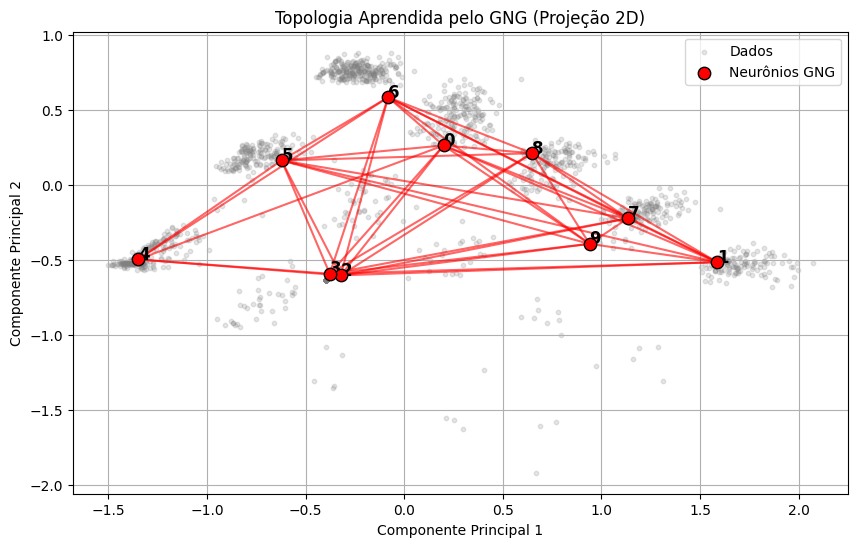

In [ ]:
plot_gng(X_pca,gng)

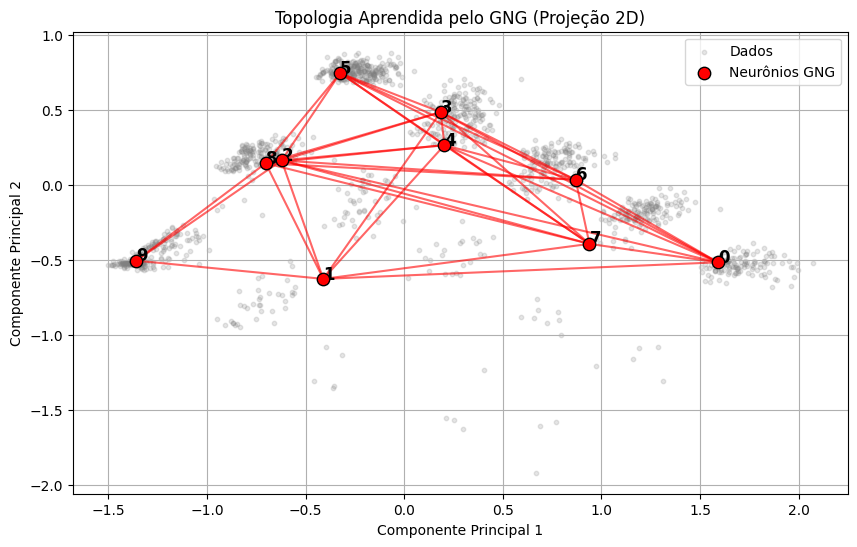

In [ ]:
plot_gng(X_scaled,gng_s)